In [8]:
# Import modules

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"   # must happen before importing jax

import argparse
import jax
import numpy as np
import numpyro
from numpyro.infer import Predictive, MCMC, NUTS
import jax.numpy as jnp
from helper import import_dataset, plot_utterance_distribution, plot_empirical_by_condition_distribution, plot_predictive_by_condition_distribution
from modelSpecification import likelihood_function_global_speaker, likelihood_function_incremental_speaker, global_speaker, incremental_speaker, incremental_semantics_jax
import matplotlib.pyplot as plt
import seaborn as sns
numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)
print(jax.__version__)


/Users/heningwang/Documents/GitHub/numpyro_adjective_modelling/jax-metal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
2026-02-23 15:38:37.142990: W pjrt_plugin/src/mps_client.cc:563] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!


Metal device set to: Apple M2 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB

0.4.20
[CpuDevice(id=0)]
0.4.20


# Posterior analysis with incremental speaker (population-level)

In [79]:
import arviz as az
inference_data_file_path = "./inference_data/mcmc_results_incremental_speaker_warmup500_samples500_chains4.nc"
idata = az.from_netcdf(inference_data_file_path)
print(az.summary(idata))
idata
# ── Extract variable names dynamically from the posterior group ──────────────  
varnames = list(idata.posterior.data_vars)  
print("Inferred variable names:", varnames)  

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     2.359  0.063   2.242    2.476      0.002    0.002    1120.0   
log_beta -0.282  0.036  -0.346   -0.213      0.001    0.001    1300.0   

          ess_tail  r_hat  
alpha       1092.0    1.0  
log_beta    1255.0    1.0  
Inferred variable names: ['alpha', 'log_beta']


## Autocorrelation analysis

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'log_beta\n0'}>,
        <Axes: title={'center': 'log_beta\n1'}>,
        <Axes: title={'center': 'log_beta\n2'}>,
        <Axes: title={'center': 'log_beta\n3'}>]], dtype=object)

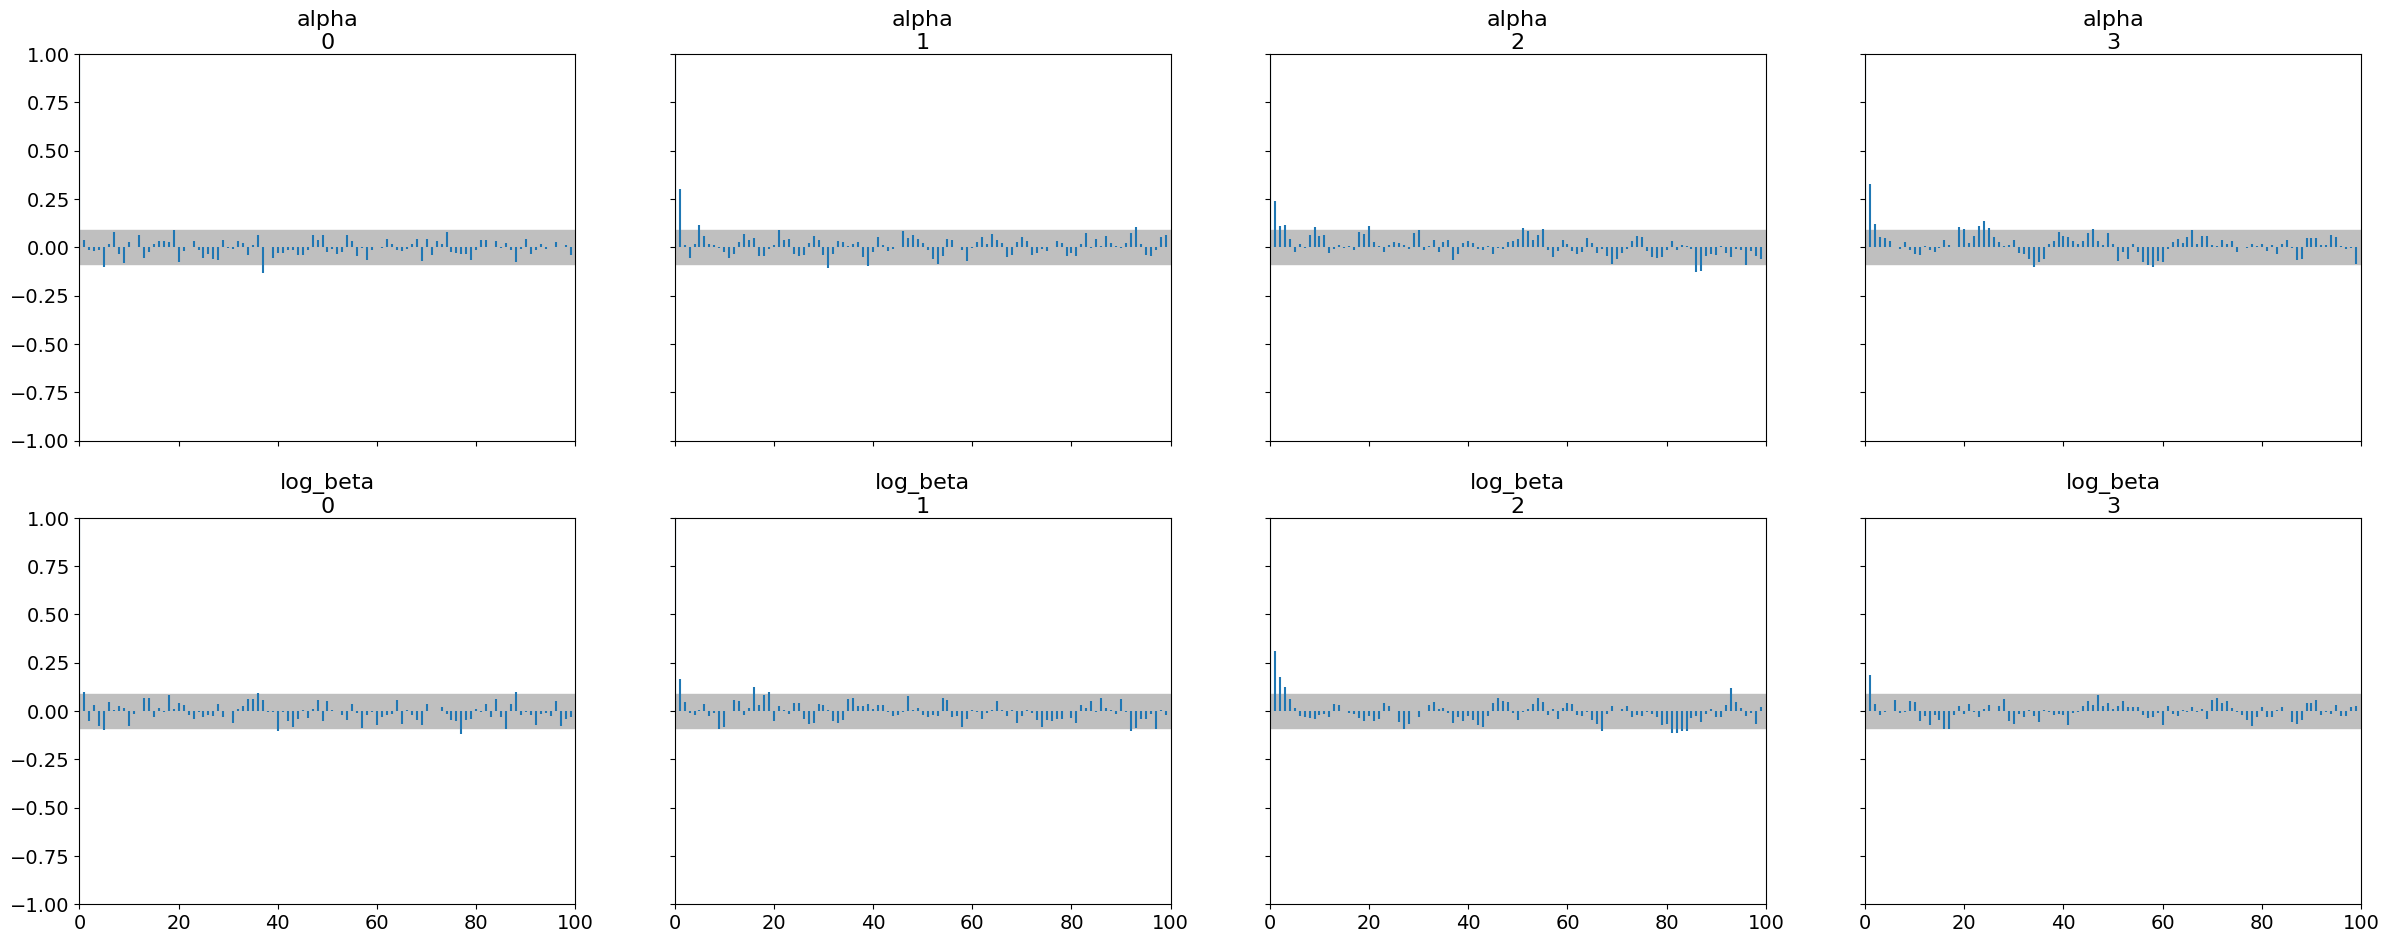

In [80]:

az.plot_autocorr(idata, var_names=varnames)


## Plot correlations between parameters

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='log_beta'>, <Axes: >]],
      dtype=object)

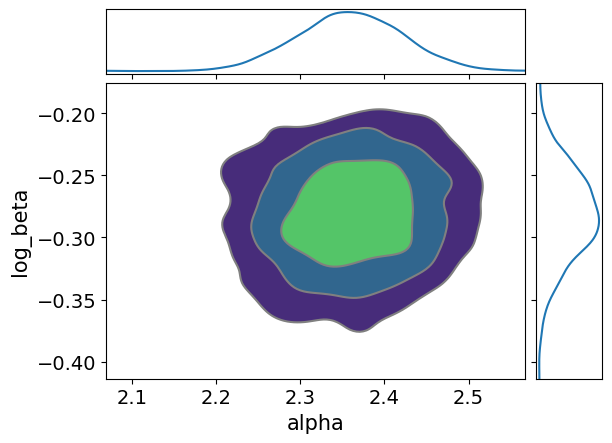

In [81]:
az.plot_pair(
    idata,
    var_names=varnames,
    kind="kde",
    marginals=True
)

## Plot prior vs posterior

array([[<Axes: >, <Axes: >, <Axes: xlabel='alpha'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='log_beta'>]], dtype=object)

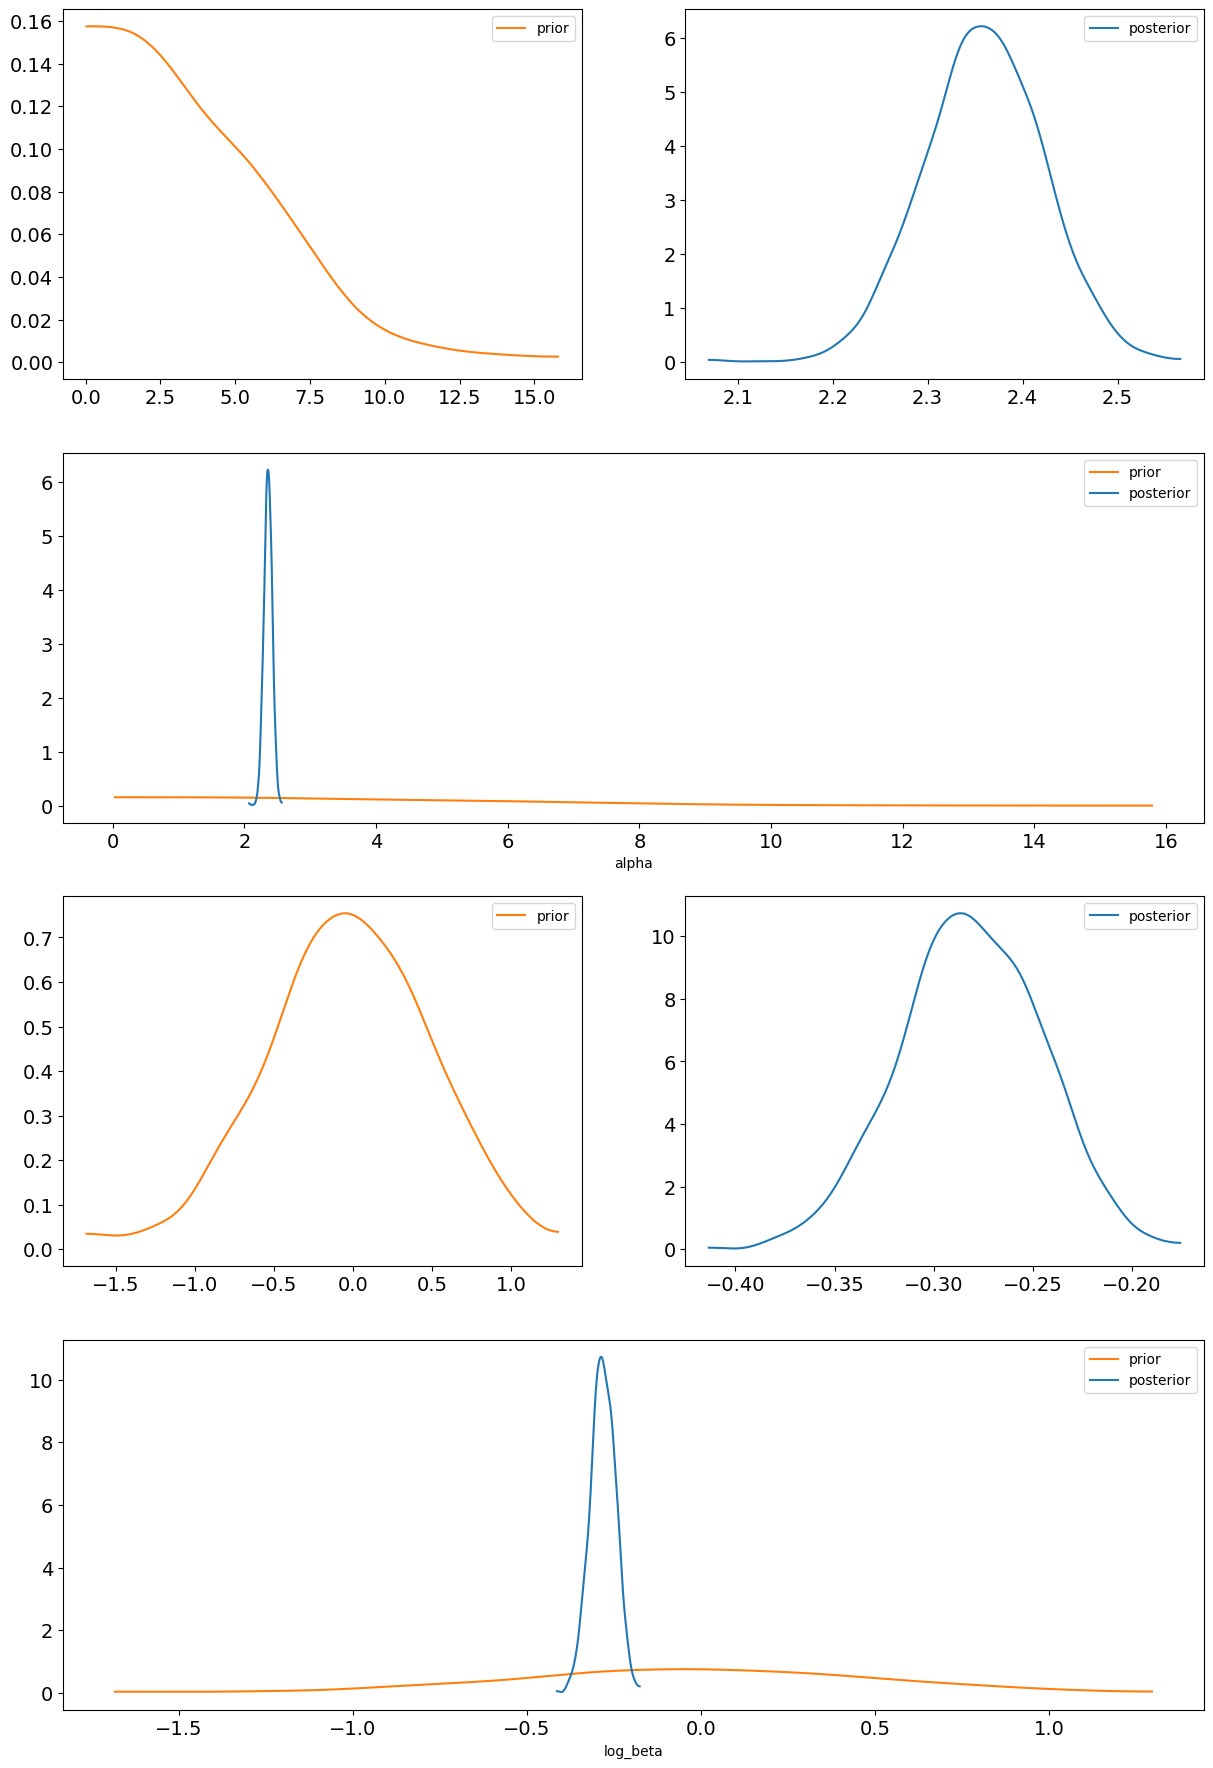

In [82]:
az.plot_dist_comparison(
    idata,
    var_names=varnames,
)

## Plot traces

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'log_beta'}>,
        <Axes: title={'center': 'log_beta'}>]], dtype=object)

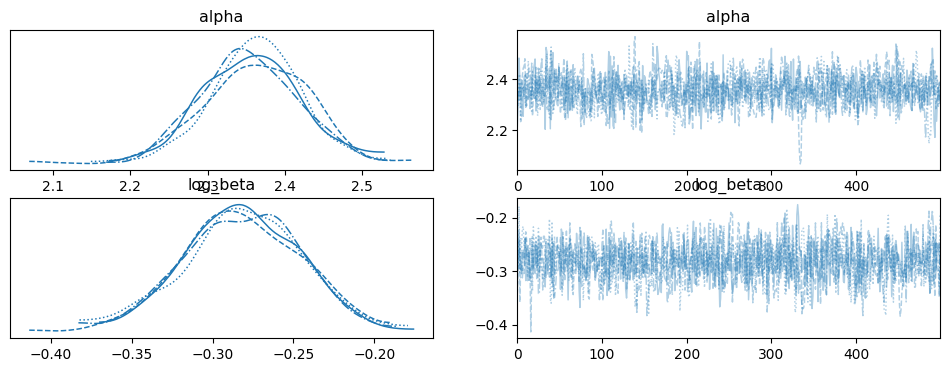

In [83]:
az.plot_trace(idata)

## Plot prior predictive, empirical, and posterior predictive distribution

Empirical Distribution by Condition


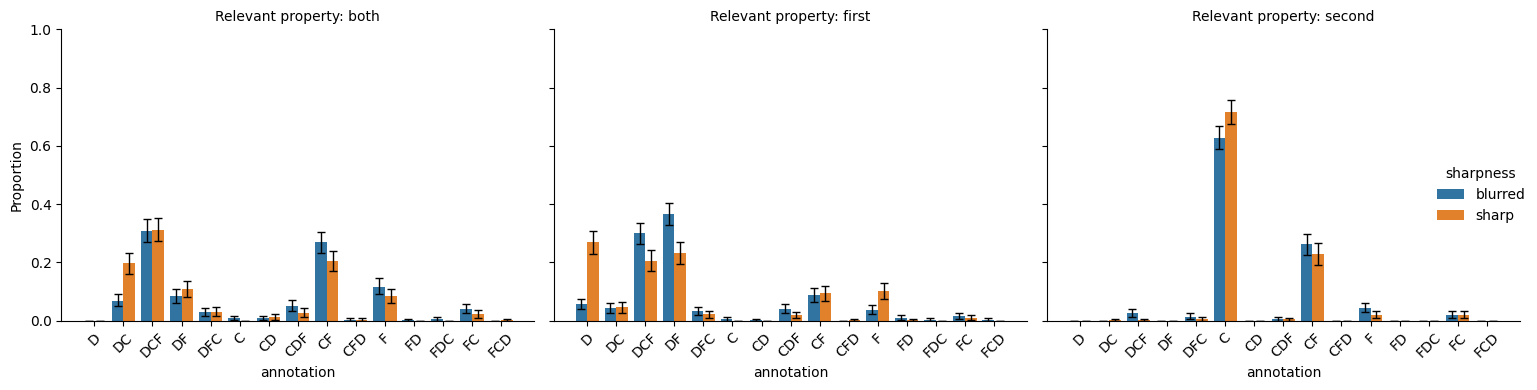

Posterior Predictive Distribution by Condition


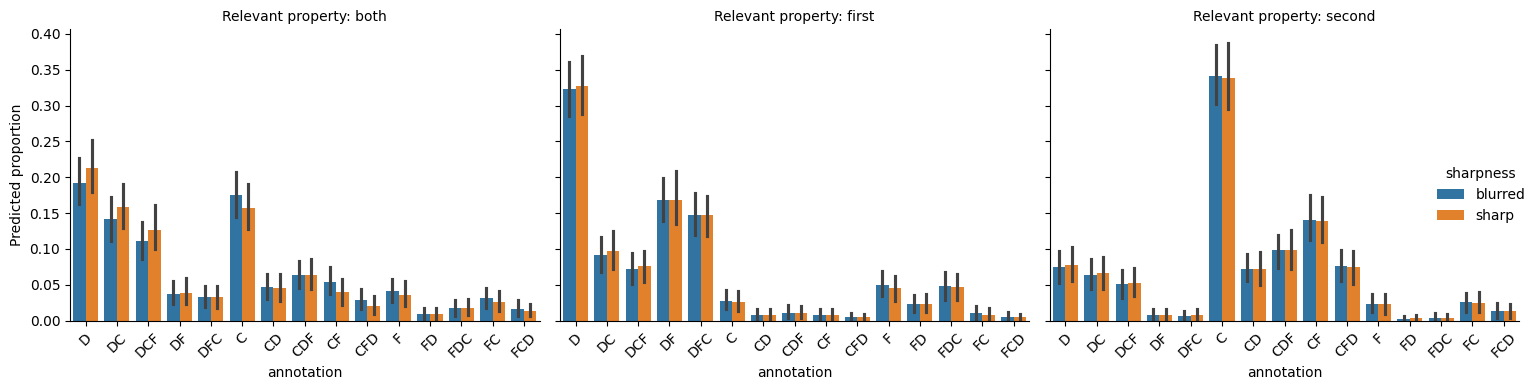

In [84]:
prior_predictive = idata.prior_predictive["obs"][0]
posterior_predictive = idata.posterior_predictive["obs"][0]

# Print titles for each plot
print("Empirical Distribution by Condition")
plot_empirical_by_condition_distribution()
#print("Prior Predictive Distribution by Condition")
#plot_predictive_by_condition_distribution(prior_predictive)
print("Posterior Predictive Distribution by Condition")
plot_predictive_by_condition_distribution(posterior_predictive)

# Posterior analysis with global speaker (population-level)

In [85]:
import arviz as az
inference_data_file_path = "./inference_data/mcmc_results_global_speaker_warmup500_samples500_chains4.nc"
idata = az.from_netcdf(inference_data_file_path)
print(az.summary(idata))
idata
# ── Extract variable names dynamically from the posterior group ──────────────  
varnames = list(idata.posterior.data_vars)  
print("Inferred variable names:", varnames)  

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     1.324  0.069   1.190    1.447      0.002    0.002    1121.0   
log_beta -0.159  0.028  -0.212   -0.105      0.001    0.001    1344.0   

          ess_tail  r_hat  
alpha       1124.0   1.00  
log_beta    1391.0   1.01  
Inferred variable names: ['alpha', 'log_beta']


## Plot autocorrelation

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'log_beta\n0'}>,
        <Axes: title={'center': 'log_beta\n1'}>,
        <Axes: title={'center': 'log_beta\n2'}>,
        <Axes: title={'center': 'log_beta\n3'}>]], dtype=object)

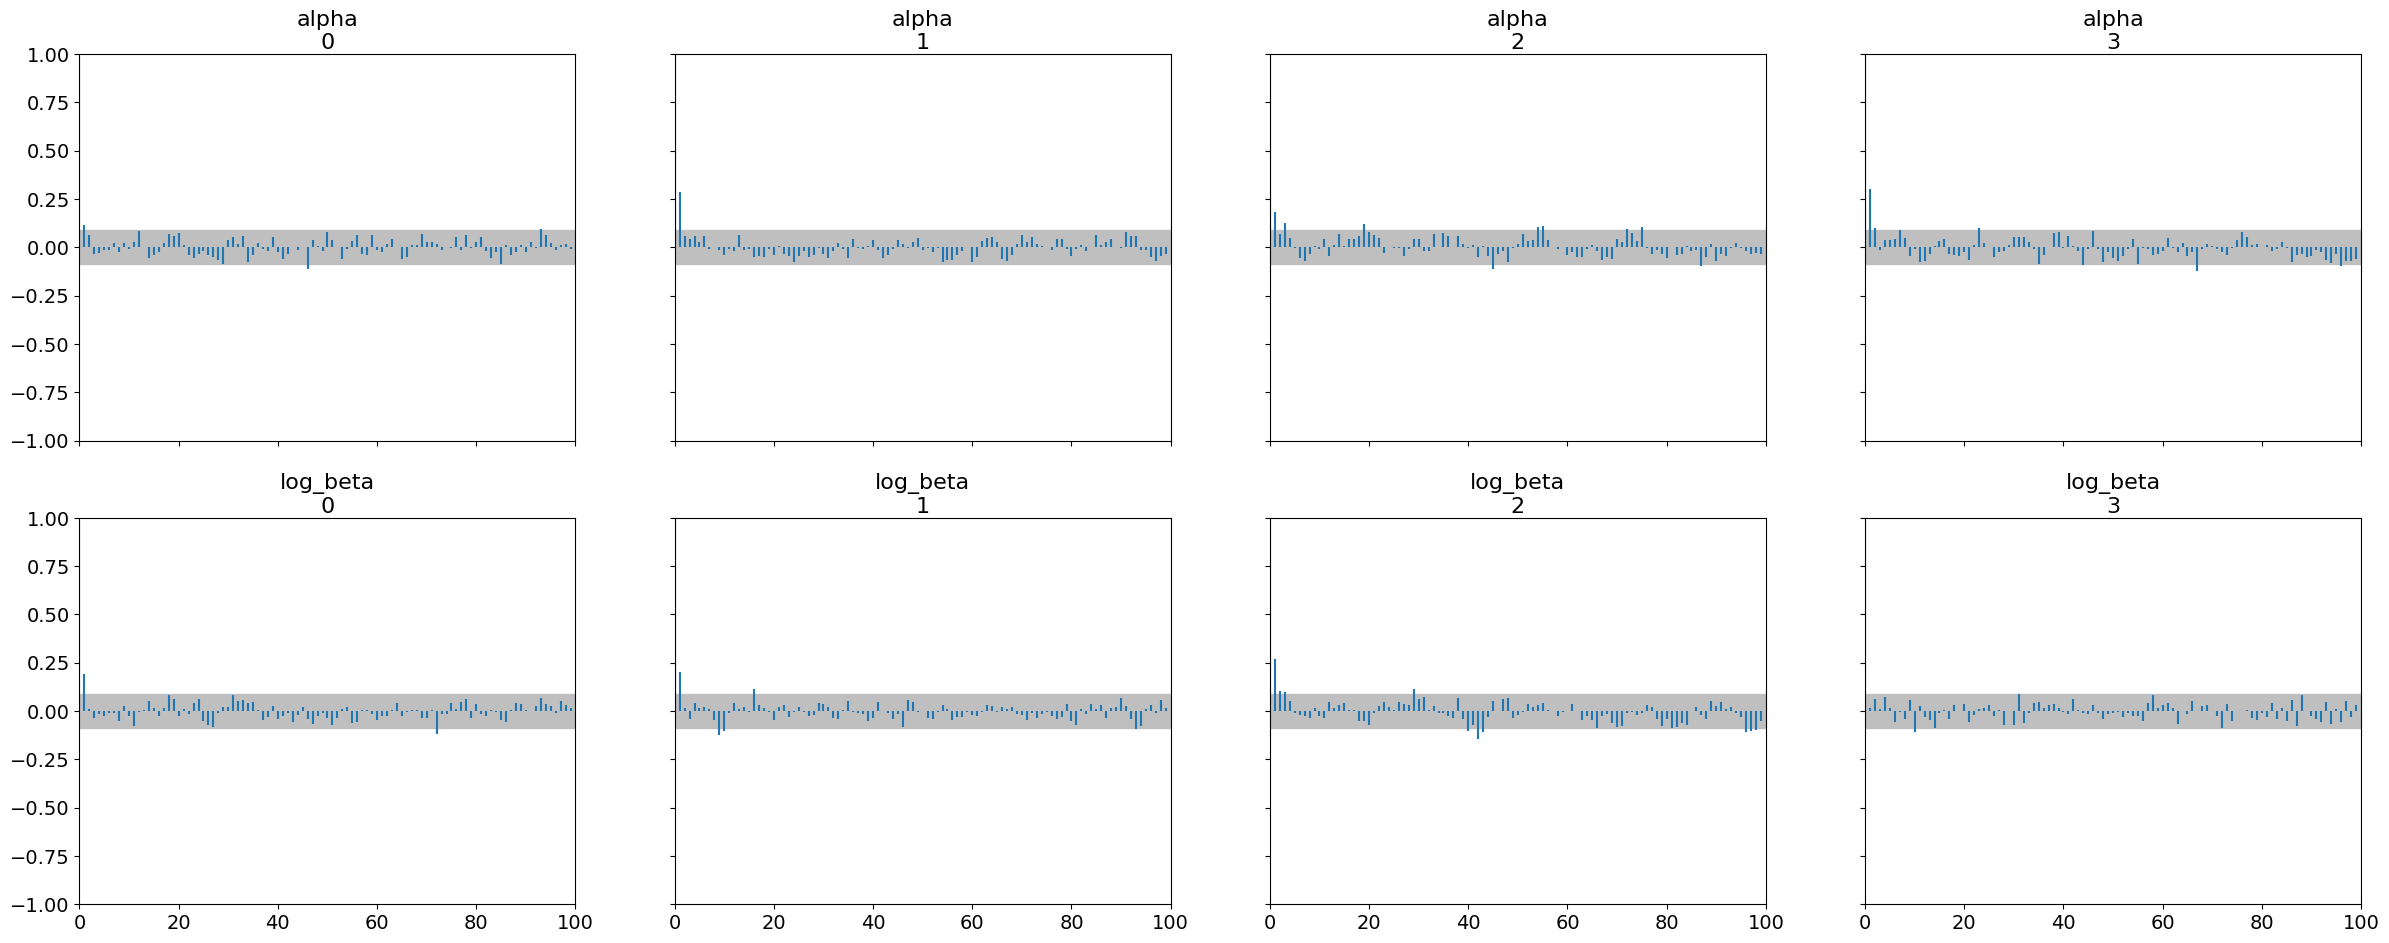

In [86]:
az.plot_autocorr(idata, var_names=varnames)

## Plot correlation

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='log_beta'>, <Axes: >]],
      dtype=object)

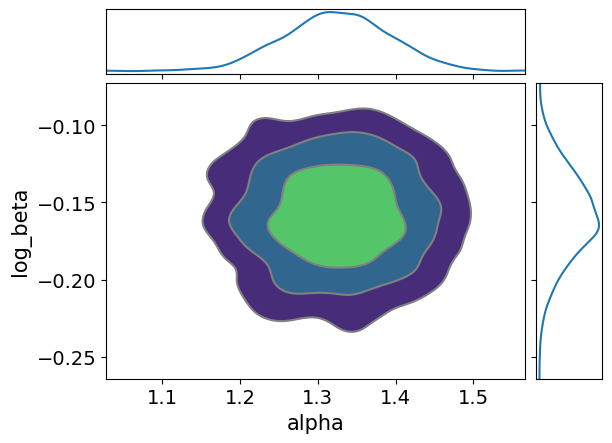

In [87]:
az.plot_pair(
    idata,
    var_names=varnames,
    kind="kde",
    marginals=True
)

## Plot posterior vs prior

array([[<Axes: >, <Axes: >, <Axes: xlabel='alpha'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='log_beta'>]], dtype=object)

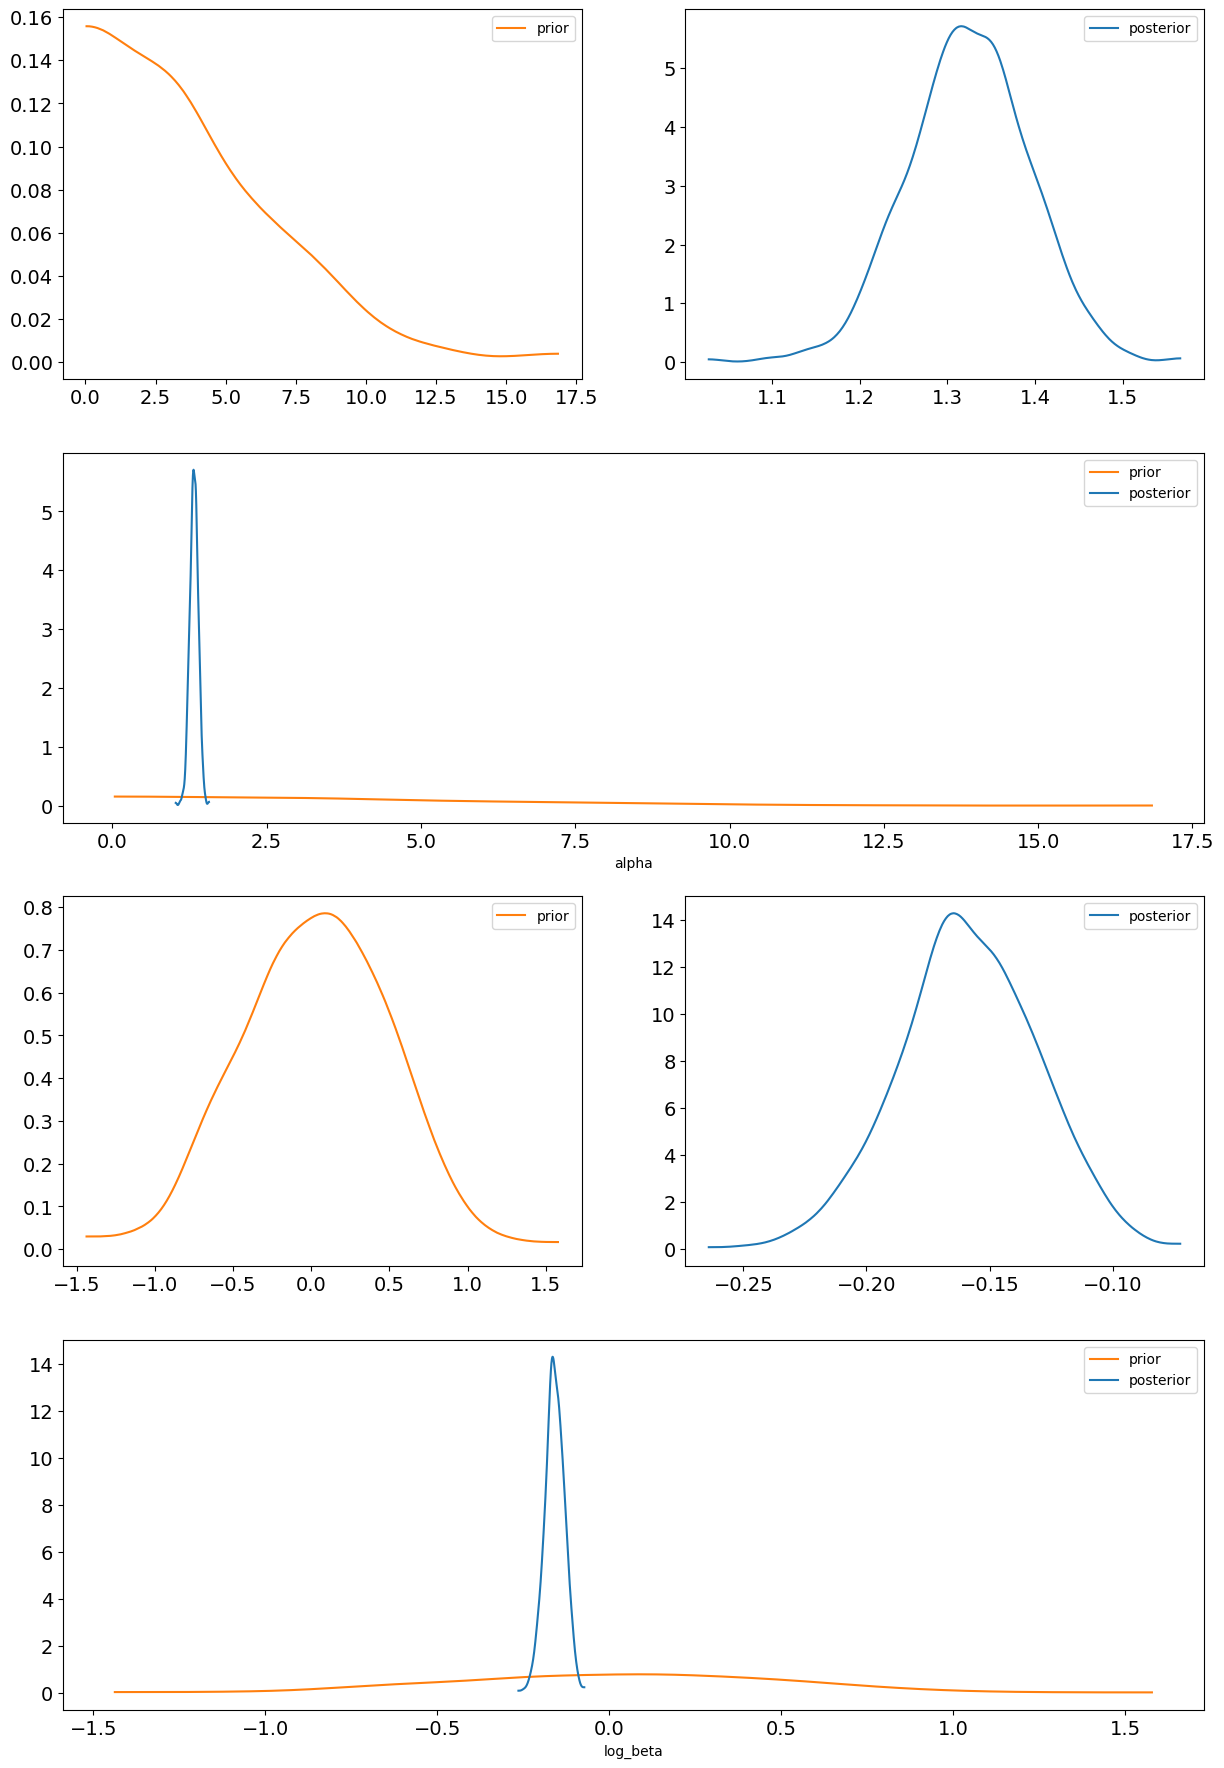

In [88]:
az.plot_dist_comparison(
    idata,
    var_names=varnames,
)

## Plot trace


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'log_beta'}>,
        <Axes: title={'center': 'log_beta'}>]], dtype=object)

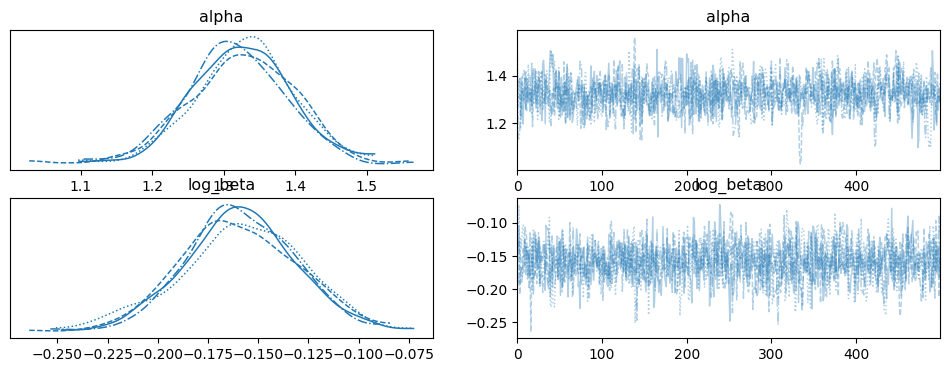

In [89]:
az.plot_trace(idata)

## Posterior predictive plot

Empirical Distribution by Condition


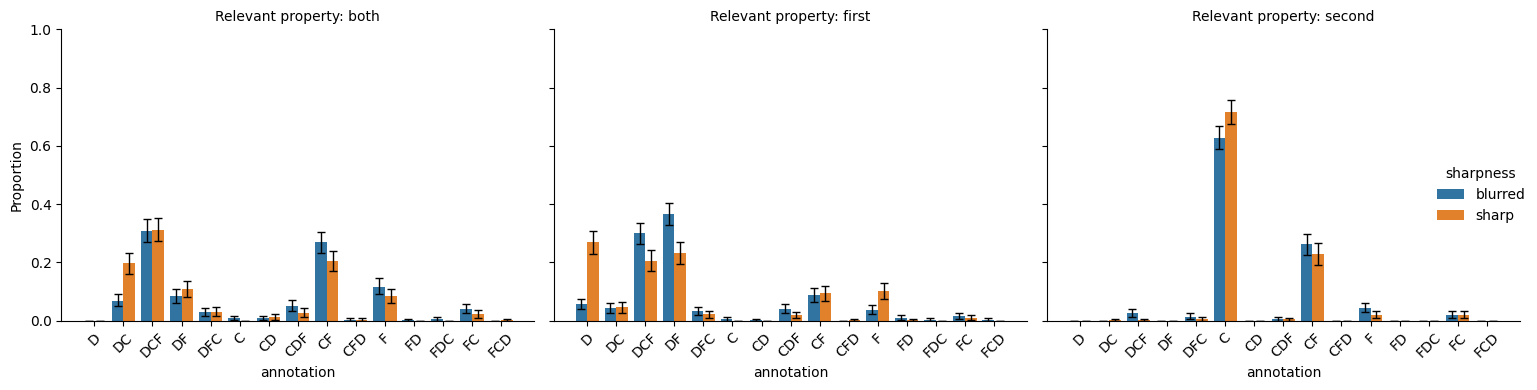

Posterior Predictive Distribution by Condition


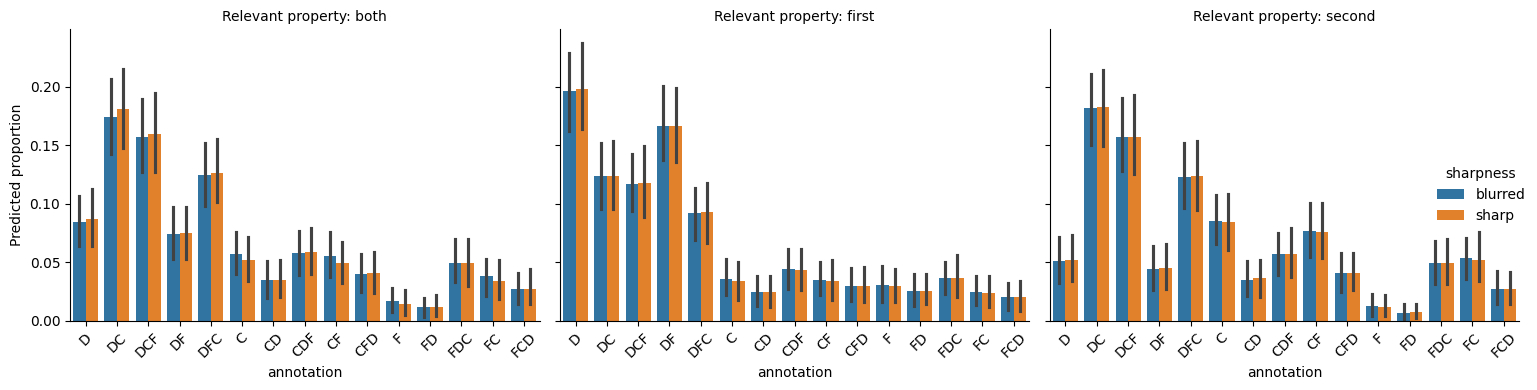

In [90]:
prior_predictive = idata.prior_predictive["obs"][0]
posterior_predictive = idata.posterior_predictive["obs"][0]

# Print titles for each plot
print("Empirical Distribution by Condition")
plot_empirical_by_condition_distribution()
#print("Prior Predictive Distribution by Condition")
#plot_predictive_by_condition_distribution(prior_predictive)
print("Posterior Predictive Distribution by Condition")
plot_predictive_by_condition_distribution(posterior_predictive)

## Model comparison

In [91]:
import arviz as az  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import matplotlib.gridspec as gridspec  

# ── Load ──────────────────────────────────────────────────────────────────────  
inc_name_last = "./inference_data/mcmc_results_incremental_speaker_last.nc"
glob_name_last = "./inference_data/mcmc_results_global_speaker_last.nc"
inc_name_chains4 = "./inference_data/mcmc_results_incremental_speaker_warmup500_samples500_chains4.nc"
glob_name_chains4 = "./inference_data/mcmc_results_global_speaker_warmup500_samples500_chains4.nc"
idata_inc = az.from_netcdf(inc_name_chains4)  
idata_glob = az.from_netcdf(glob_name_chains4)  
# ── Compute LOO for each model ────────────────────────────────────────────────
#    LOO = Leave-One-Out cross-validation via PSIS
#    More reliable than WAIC for finite samples

loo_inc  = az.loo(idata_inc,  var_name="obs", pointwise=True)
loo_glob = az.loo(idata_glob, var_name="obs", pointwise=True)

print("=== LOO: Incremental ===")
print(loo_inc)
print("\n=== LOO: Global ===")
print(loo_glob)

# Key output fields:
#
#   elpd_loo    : expected log pointwise predictive density
#                 HIGHER = better predictive accuracy
#   p_loo       : effective number of parameters
#                 if p_loo >> n_params → model is overfit / misspecified
#   looic       : -2 * elpd_loo  (like AIC scale, LOWER = better)
#   se          : standard error of elpd_loo
#   warning     : True if any Pareto k̂ > 0.7
#
#   Pareto k̂ interpretation:
#     k̂ < 0.5   : excellent  ✅
#     k̂ < 0.7   : good       ✅
#     k̂ < 1.0   : bad        ⚠️  → importance weights unreliable
#     k̂ ≥ 1.0   : very bad   ❌  → LOO invalid for those points




=== LOO: Incremental ===
Computed from 2000 posterior samples and 3196 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -7070.82    57.74
p_loo        1.81        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3196  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


=== LOO: Global ===
Computed from 2000 posterior samples and 3196 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -7792.47    36.32
p_loo        1.29        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3196  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [92]:
# ── Compare models ────────────────────────────────────────────────────────────
comparison = az.compare(
    {
        "incremental": idata_inc,
        "global":      idata_glob,
    },
    ic      = "loo",        # or "waic" — LOO preferred
    method  = "stacking",   # "stacking" or "BB-pseudo-BMA"
    var_name= "obs",
)

print(comparison)

# Output table columns:
#
#   rank      : 0 = best model
#   elpd_loo  : higher is better
#   p_loo     : effective parameters
#   elpd_diff : difference from best model (best = 0.0)
#   weight    : stacking weight ∈ [0, 1], sums to 1
#   se        : se of elpd_loo
#   dse       : se of elpd_diff (use THIS for significance, not se)
#   warning   : Pareto k̂ issues present?
#
# ── Significance rule of thumb ────────────────────────────────────────────────
#   |elpd_diff| > 2 * dse   → meaningful difference
#   |elpd_diff| < 2 * dse   → models indistinguishable by LOO

best = comparison.index[0]
diff  = comparison["elpd_diff"].iloc[1]
dse   = comparison["dse"].iloc[1]
ratio = abs(diff) / dse if dse > 0 else float("inf")

print(f"\nBest model : {best}")
print(f"elpd_diff  : {diff:.2f}")
print(f"dse        : {dse:.2f}")
print(f"|diff|/dse : {ratio:.2f}  {'← meaningful' if ratio > 2 else '← not significant'}")


             rank     elpd_loo     p_loo   elpd_diff    weight         se  \
incremental     0 -7070.820572  1.812666    0.000000  0.846128  57.742861   
global          1 -7792.471197  1.290781  721.650625  0.153872  36.322019   

                   dse  warning scale  
incremental   0.000000    False   log  
global       47.674179    False   log  

Best model : incremental
elpd_diff  : 721.65
dse        : 47.67
|diff|/dse : 15.14  ← meaningful


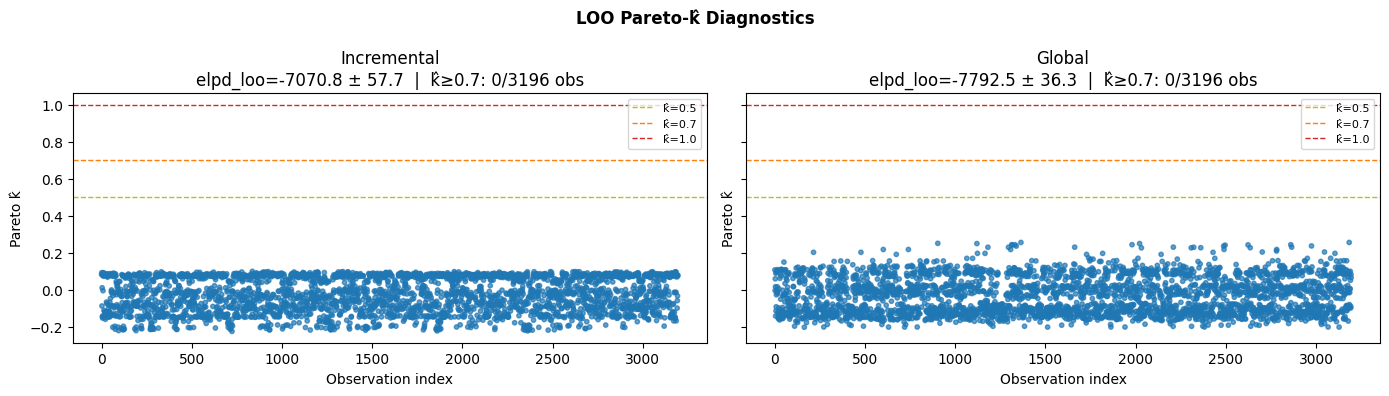

In [93]:
# ── Pareto k̂ per observation ─────────────────────────────────────────────────
# Tells you WHERE each model struggles

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (name, idata, loo) in zip(axes, [
    ("Incremental", idata_inc,  loo_inc),
    ("Global",      idata_glob, loo_glob),
]):
    k_vals = loo.pareto_k.values                              # (N,)
    n_obs  = len(k_vals)
    colors = np.where(k_vals >= 1.0, "#d62728",   # very bad
             np.where(k_vals >= 0.7, "#ff7f0e",   # bad
             np.where(k_vals >= 0.5, "#bcbd22",   # ok
                                     "#1f77b4"))) # good

    ax.scatter(np.arange(n_obs), k_vals, c=colors, s=10, alpha=0.7)
    ax.axhline(0.5, color="#bcbd22", ls="--", lw=1, label="k̂=0.5")
    ax.axhline(0.7, color="#ff7f0e", ls="--", lw=1, label="k̂=0.7")
    ax.axhline(1.0, color="#d62728", ls="--", lw=1, label="k̂=1.0")

    n_bad = np.sum(k_vals >= 0.7)
    ax.set_title(
        f"{name}\n"
        f"elpd_loo={loo.elpd_loo:.1f} ± {loo.se:.1f}  |  "
        f"k̂≥0.7: {n_bad}/{n_obs} obs"
    )
    ax.set_xlabel("Observation index")
    ax.set_ylabel("Pareto k̂")
    ax.legend(fontsize=8)

plt.suptitle("LOO Pareto-k̂ Diagnostics", fontweight="bold")
plt.tight_layout()
plt.show()


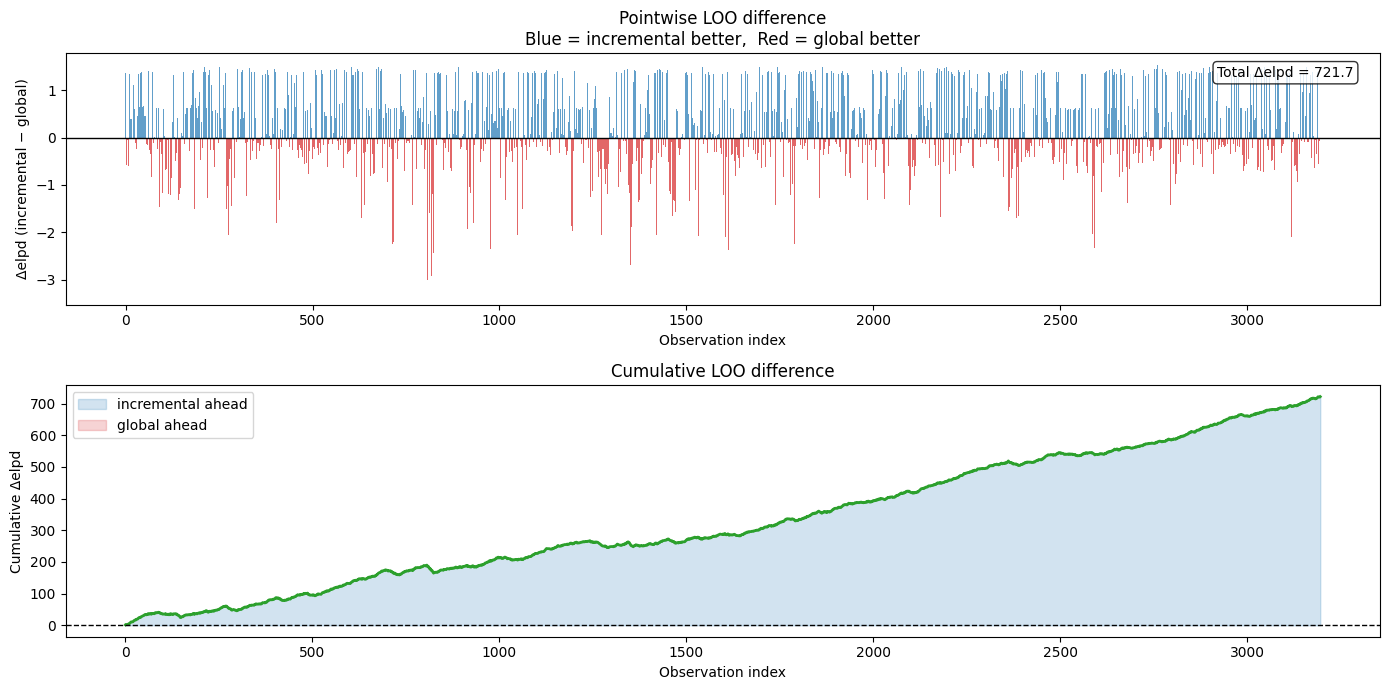

In [94]:
# ── Per-observation: which model wins where? ──────────────────────────────────
# pointwise elpd_diff > 0  → incremental better on that trial
# pointwise elpd_diff < 0  → global better on that trial

pw_inc  = loo_inc.loo_i.values                               # (N,)
pw_glob = loo_glob.loo_i.values                              # (N,)
pw_diff = pw_inc - pw_glob                                   # (N,)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Top: pointwise difference ─────────────────────────────────────────────────
ax = axes[0]
colors = np.where(pw_diff > 0, "#1f77b4", "#d62728")
ax.bar(np.arange(len(pw_diff)), pw_diff, color=colors, width=1.0, alpha=0.7)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Observation index")
ax.set_ylabel("Δelpd (incremental − global)")
ax.set_title(
    "Pointwise LOO difference\n"
    "Blue = incremental better,  Red = global better"
)

# Annotate total
total_diff = pw_diff.sum()
ax.text(0.98, 0.95, f"Total Δelpd = {total_diff:.1f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# ── Bottom: cumulative difference ─────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(np.cumsum(pw_diff), color="#2ca02c", lw=2)
ax2.axhline(0, color="black", lw=1, ls="--")
ax2.fill_between(np.arange(len(pw_diff)), np.cumsum(pw_diff), 0,
                 where=np.cumsum(pw_diff) > 0,
                 color="#1f77b4", alpha=0.2, label="incremental ahead")
ax2.fill_between(np.arange(len(pw_diff)), np.cumsum(pw_diff), 0,
                 where=np.cumsum(pw_diff) < 0,
                 color="#d62728", alpha=0.2, label="global ahead")
ax2.set_xlabel("Observation index")
ax2.set_ylabel("Cumulative Δelpd")
ax2.set_title("Cumulative LOO difference")
ax2.legend()

plt.tight_layout()
plt.show()


In [95]:
# ── Summary report ────────────────────────────────────────────────────────────
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison.to_string())
print()

for name, loo in [("Incremental", loo_inc), ("Global", loo_glob)]:
    k = loo.pareto_k.values
    print(f"{name}:")
    print(f"  elpd_loo = {loo.elpd_loo:.2f} ± {loo.se:.2f}")
    print(f"  p_loo    = {loo.p_loo:.2f}")
    print(f"  k̂ < 0.5  : {(k < 0.5).sum()} obs  (good)")
    print(f"  k̂ ∈[0.5, 0.7): {((k>=0.5)&(k<0.7)).sum()} obs  (ok)")
    print(f"  k̂ ∈[0.7, 1.0): {((k>=0.7)&(k<1.0)).sum()} obs  (bad ⚠️)")
    print(f"  k̂ ≥ 1.0  : {(k >= 1.0).sum()} obs  (very bad ❌)")
    print()

# ── Decision table ────────────────────────────────────────────────────────────
print("""
Result               Interpretation
─────────────────────────────────────────────────────────────
|elpd_diff| < 2*dse  Models equivalent — incremental adds no
                     predictive value over global

|elpd_diff| > 2*dse  
  incremental wins   Incremental processing matters for fit
  global wins        Global speaker is sufficient / simpler
  
p_loo >> n_params    Model overfit or misspecified
  (e.g. p_loo > 5    (only 2 free params: phi_color, phi_form)
   for 2-param model)

weight ≈ 1.0         One model dominates stacking ensemble
weight ≈ 0.5/0.5     Models equally predictive — consider
                     averaging predictions
""")


MODEL COMPARISON SUMMARY
             rank     elpd_loo     p_loo   elpd_diff    weight         se        dse  warning scale
incremental     0 -7070.820572  1.812666    0.000000  0.846128  57.742861   0.000000    False   log
global          1 -7792.471197  1.290781  721.650625  0.153872  36.322019  47.674179    False   log

Incremental:
  elpd_loo = -7070.82 ± 57.74
  p_loo    = 1.81
  k̂ < 0.5  : 3196 obs  (good)
  k̂ ∈[0.5, 0.7): 0 obs  (ok)
  k̂ ∈[0.7, 1.0): 0 obs  (bad ⚠️)
  k̂ ≥ 1.0  : 0 obs  (very bad ❌)

Global:
  elpd_loo = -7792.47 ± 36.32
  p_loo    = 1.29
  k̂ < 0.5  : 3196 obs  (good)
  k̂ ∈[0.5, 0.7): 0 obs  (ok)
  k̂ ∈[0.7, 1.0): 0 obs  (bad ⚠️)
  k̂ ≥ 1.0  : 0 obs  (very bad ❌)


Result               Interpretation
─────────────────────────────────────────────────────────────
|elpd_diff| < 2*dse  Models equivalent — incremental adds no
                     predictive value over global

|elpd_diff| > 2*dse  
  incremental wins   Incremental processing matters for fit
  gl

## Generate a correlation plot with model predictions and empirical data

# Posterior analysis with model comparison (population-level)

# Posterior analysis with incremental speaker (hierarchical-level)

# Posterior analysis with global speaker (hierarchical-level)